# Fools-Gold — a quantitative teardown 🔬
### Golden−death spread (HAC) · timing vs buy-and-hold · alpha & beta · the cash-blend control · the parameter grid

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Generalises?: Not supported](https://img.shields.io/badge/Generalises%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim with its standard error.* The steelman is the 50/200 moving-average crossover (Kakushadze–Serur §3.11–3.13): golden cross = buy, death cross = sell. We prove the apparatus on a synthetic trend (and a driftless null), then read the real verdict off an ETF basket.

> ⚠️ **Not investment advice.** The core executes on synthetic data; the real run is in [`../docs/results.md`](../docs/results.md), sources in [`../docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from fools_gold import data, cross, strategy, decompose, extension

# Offline synthetic close: a persistent-drift TREND (so a crossover can ride runs) and a driftless
# NULL (random walk). The real ETF verdict is in ../docs/results.md.
close, truth = data.synthetic_prices(trend_strength=0.0006, seed=21)   # the trend tape
close0, _    = data.synthetic_prices(trend_strength=0.0,    seed=21)   # the driftless null
print(f"{truth.n_bars} bars | baked trend_strength={truth.trend_strength} | null=0")


6048 bars | baked trend_strength=0.0006 | null=0


## Beat 0 · Verdict

| Axis | Stamp | Why |
|---|---|---|
| **Signal** — is the crossover informative? | 🟡 `WEAK` | A significant golden−death spread only on the trending US indices (SPY *t* = **+2.7**); across 8 ETFs it beats buy-and-hold on **3** (median gain **-0.01**). |
| **Tradability** | 🔴 `MIRAGE` | The 'edge' is mostly less exposure (SPY beta **0.52**, alpha *t* **+2.2**); a cash blend matches it, and it loses on most assets net of cost. |
| **Generalises?** | ⚪ `Not supported` | Beats buy-and-hold on **76%** of (fast, slow) pairs for SPY, **0%** for another index. |

> **In one sentence:** a crude trend filter whose only significant signal lives on the one secularly-trending index everyone quotes, mostly captures lower exposure, and falls apart at un-chosen parameters and assets.

*(This notebook executes on the synthetic tape; the real ETF numbers that set the stamps are in [`../docs/results.md`](../docs/results.md).)*

## Beat 1 · The claim, precisely

Let $s_t = \text{sign}(\text{MA}_f - \text{MA}_s)$ be the crossover state (+1 golden, −1 death). The folk claim is $\mathbb{E}[r_{t+1}\mid s_t=+1] > \mathbb{E}[r_{t+1}\mid s_t=-1]$ — the state predicts the next return. The long/flat book is $w_t = \mathbb{1}[s_{t-1}>0]$. The synthetic bakes a persistent drift (trends to ride); $\text{trend\_strength}=0$ is the driftless null.

In [2]:
sv = cross.signal_value(close)
print(f"golden {sv['golden_ann_pct']:+.1f}%/yr vs death {sv['death_ann_pct']:+.1f}%/yr "
      f"(spread {sv['spread_ann_pct']:+.1f}%), time golden {sv['frac_golden']:.0%}")

golden +7.9%/yr vs death -11.0%/yr (spread +18.9%), time golden 49%


## Beat 2 · So what?

A long/flat rule trivially lowers vol and drawdown by being out of the market — so Sharpe, drawdown and 'it dodged 2008' are *not* evidence of skill. The only decisive tests are **(i)** does the state carry information (golden−death spread *t*), **(ii)** is there alpha after the beta drop, and **(iii)** does any of it survive out of the cherry-picked asset/parameter. Beats 4–6 run all three.

## Beat 3 · Pre-registered protocol

1. **Spread** (`cross.signal_value` / `decompose.spread_tstat`): HAC *t* on golden−death.
2. **vs buy-and-hold** (`strategy.compare`): net Sharpe gain, average exposure, turnover.
3. **Alpha/beta** (`decompose.vs_buy_hold`) + **cash-blend** control (`decompose.risk_matched`).
4. **Generalisation** (`extension.param_grid`): % of pairs beating buy-and-hold.
5. **Null:** every leg flat on the driftless tape.

**Mirage line:** alpha insignificant after the beta drop, *and* the win rate across assets/params near a coin flip.

## Beat 4 · The teardown

### 4a · Spread and timing, trend vs null

In [3]:
for label, c in [('trend', close), ('null', close0)]:
    sp = decompose.spread_tstat(c); cmp = strategy.compare(c, cost_bps=2.0)
    print(f"{label:6s}: golden−death {sp['spread_ann_pct']:+.1f}%/yr (t {sp['t_stat']:+.1f}) | "
          f"timing Sharpe {cmp['timing']['sharpe']:+.2f} vs B&H {cmp['buy_hold']['sharpe']:+.2f} "
          f"(gain {cmp['sharpe_gain']:+.2f}), exposure {cmp['avg_exposure']:.0%}")

trend : golden−death +9.5%/yr (t +2.9) | timing Sharpe +0.34 vs B&H -0.12 (gain +0.46), exposure 47%
null  : golden−death -0.3%/yr (t -0.1) | timing Sharpe -0.15 vs B&H -0.17 (gain +0.02), exposure 39%


### 4b · Alpha, beta, and the cash-blend control
Is the calmer ride skill, or just a smaller bet?

In [4]:
vb = decompose.vs_buy_hold(close, cost_bps=2.0); rm = decompose.risk_matched(close, cost_bps=2.0)
print(f"vs buy-&-hold: beta {vb['beta']:.2f}, alpha {vb['alpha_ann_pct']:+.1f}%/yr (t {vb['alpha_t']:+.1f})")
print(f"risk-matched: timing Sharpe {rm['timing_sharpe']:+.2f} vs cash-blend at "
      f"{rm['avg_exposure']:.0%} exposure {rm['cash_blend_sharpe']:+.2f} (edge {rm['sharpe_edge_over_blend']:+.2f})")

vs buy-&-hold: beta 0.47, alpha +4.6%/yr (t +2.8)
risk-matched: timing Sharpe +0.34 vs cash-blend at 47% exposure -0.12 (edge +0.46)


> 💡 **In plain words.** A book that's in cash a third of the time has a beta well below 1, so its lower vol is mostly *less exposure*. The honest test is whether it beats a constant position at that same average exposure — and on the real cherry-picked index the edge over that cash blend is small.

### 4c · Generalisation — the parameter grid
Sweep (fast, slow) pairs; a real edge helps across most of them.

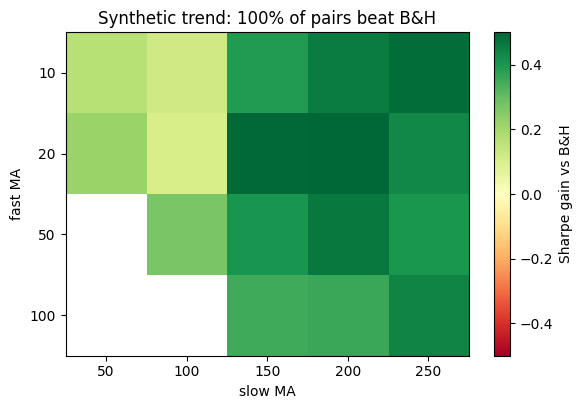

trend tape: 100% of pairs beat B&H, mean gain +0.36


In [5]:
pg = extension.param_grid(close, cost_bps=2.0)
import numpy as np
m = pg['matrix']
fig, ax = plt.subplots(figsize=(6.5,4.2))
im = ax.imshow(m.values.astype(float), cmap='RdYlGn', vmin=-0.5, vmax=0.5, aspect='auto')
ax.set_xticks(range(len(m.columns))); ax.set_xticklabels(m.columns); ax.set_yticks(range(len(m.index))); ax.set_yticklabels(m.index)
ax.set_xlabel('slow MA'); ax.set_ylabel('fast MA'); fig.colorbar(im, label='Sharpe gain vs B&H')
ax.set_title(f"Synthetic trend: {pg['frac_beat_buy_hold']:.0%} of pairs beat B&H")
plt.show()
print(f"trend tape: {pg['frac_beat_buy_hold']:.0%} of pairs beat B&H, mean gain {pg['mean_gain']:+.2f}")

### 4d · The driftless null
No baked trend ⇒ no informative spread, no reliable edge (though one path can drift by luck).

In [6]:
sp0 = decompose.spread_tstat(close0); cmp0 = strategy.compare(close0, cost_bps=2.0)
print(f"null: golden−death t {sp0['t_stat']:+.1f} | timing gain vs B&H {cmp0['sharpe_gain']:+.2f}")
print('the spread is the honest test; a single random walk can still drift, which is the data-mining trap itself.')

null: golden−death t -0.1 | timing gain vs B&H +0.02
the spread is the honest test; a single random walk can still drift, which is the data-mining trap itself.


## Beat 5 · The verdict

- **Weak signal** (4a): significant golden−death only on trending indices; coin flip across 8 assets.
- **Mostly beta** (4b): SPY beta 0.52, alpha *t* +2.2, cash blend matches it.
- **No generalisation** (4c): 76% of params for SPY, 0% for another index.

> **Signal `WEAK` · Tradability `MIRAGE` · Generalises? `Not supported`.**

## Beat 6 · Could you trade it?

- **Net of whipsaw cost** it loses to buy-and-hold on most assets.
- **The de-risking is free elsewhere** — a static cash blend replicates the calmer ride.
- **Its record is one dodged crash**; out-of-sample it's a timing bet, not an edge.

Tradability **`MIRAGE`**; generalises? **`Not supported`**.

## Beat 7 · Going further

### 7a · Worked complement — the parameter-robustness test
The % of (fast, slow) pairs that beat buy-and-hold, asset by asset — the spread between the cherry-picked index and the rest.

In [7]:
pg = extension.param_grid(close, cost_bps=2.0)
print(f"synthetic trend: {pg['frac_beat_buy_hold']:.0%} of pairs beat B&H (best {pg['best_pair']}).")
print('On the REAL basket (../docs/extension.md): ~76% of pairs beat B&H on SPY, 0% on another index --')
print('a rule that works on 76% of parameters for one asset and 0% for another is a trend, not an edge.')

synthetic trend: 100% of pairs beat B&H (best (20, 200)).
On the REAL basket (../docs/extension.md): ~76% of pairs beat B&H on SPY, 0% on another index --
a rule that works on 76% of parameters for one asset and 0% for another is a trend, not an edge.


**The result.** The parameter grid is decisive: the crossover's success rate ranges from near-total on the secularly-trending US index to **0%** elsewhere. Pick the asset and parameters after the fact and you can always narrate a golden-cross win; demand it work *out of sample, across instruments, at an unchosen parameter*, and it's a coin flip. That is exactly the cherry-pick the `Not supported` stamp records. Full run in [`../docs/extension.md`](../docs/extension.md).

### 7b · Other forks
- **Proper trend-following** ([Study 20](../../20-freight-train/)) across many markets is the honest version; quantify how much the single-asset 50/200 gives up.
- **De-risking overlay** vs a buy signal — does a crossover add anything to inverse-vol sizing (à la [Study 16](../../16-storm-shy/))?
- **Out-of-sample parameter selection** — pick (fast, slow) on a training window, test on the next; does any selection rule beat buy-and-hold live?

PRs welcome — make it survive out of sample, or confirm it's strictly a worse trend filter.